<a href="https://colab.research.google.com/github/Ibarra1812/Telecom-X-Parte-2/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fase 1: Extracción y Preparación de Datos Tratados


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Entrega de TELECOM-X/Parte 2/df_original_processed.csv')
df.head()

,id_cliente,abandono,genero,adulto_mayor,posee_pareja,posee_dependientes,permanencia,servicio_telefono,multiples_lineas,servicio_internet,...,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_sin_papel,metodo_pago,cargos_mensuales,Charges.Total,cargos_totales,cargos_diarios
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.6,593.3,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.4,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fibra óptica,...,No,No,No,Mensual,Sí,Cheque electrónico,73.9,280.85,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fibra óptica,...,No,Sí,Sí,Mensual,Sí,Cheque electrónico,98.0,1237.85,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fibra óptica,...,Sí,Sí,No,Mensual,Sí,Cheque enviado por correo,83.9,267.4,267.40,2.796667


## Fase 2: Ingeniería de Variables y Preparación de df_Learning
*En esta etapa creamos un nuevo DataFrame específico para el modelo:*
1. **Nueva Feature:** `tiene_internet` (binaria) para identificar acceso general al servicio.
2. **Preservación de Categorías:** Mantenemos los tipos de tecnología en `servicio_internet` para posterior codificación.
3. **Mapeo Binario:** Estandarizamos las respuestas 'Sí/No' a 1 y 0.

In [55]:
df_Learning = df.copy()

gender_map = {'Femenino': 1, 'Masculino': 0}
df_Learning['genero'] = df_Learning['genero'].map(gender_map).astype(int)

binary_map = {'Sí': 1, 'No': 0}

simple_binary_cols = [
    'abandono', 'posee_pareja', 'posee_dependientes',
    'servicio_telefono', 'factura_sin_papel'
]

for col in simple_binary_cols:
    if col in df_Learning.columns:
        df_Learning[col] = df_Learning[col].map(binary_map).astype(int)


service_map = {'Sí': 1, 'No': 0, 'Sin servicio de teléfono': 0, 'Sin servicio de internet': 0}

service_cols = [
    'multiples_lineas', 'seguridad_online', 'respaldo_online',
    'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]


for col in service_cols:
    if col in df_Learning.columns:
        df_Learning[col] = df_Learning[col].map(service_map).astype(int)


internet_service_map = {'DSL': 1, 'Fibra óptica': 1, 'No': 0}
df_Learning['tiene_internet'] = df_Learning['servicio_internet'].map(internet_service_map)

# Now apply one-hot encoding to the specified columns
df_Learning = pd.get_dummies(df_Learning, columns=['servicio_internet', 'tipo_contrato', 'metodo_pago'], drop_first=False,dtype=int)
df_Learning.head()

,id_cliente,abandono,genero,adulto_mayor,posee_pareja,posee_dependientes,permanencia,servicio_telefono,multiples_lineas,seguridad_online,...,servicio_internet_DSL,servicio_internet_Fibra óptica,servicio_internet_No,tipo_contrato_Anual,tipo_contrato_Bienal,tipo_contrato_Mensual,metodo_pago_Cheque electrónico,metodo_pago_Cheque enviado por correo,metodo_pago_Tarjeta de crédito (automático),metodo_pago_Transferencia bancaria (automática)
0,0002-ORFBO,0,1,0,1,1,9,1,0,0,...,1,0,0,1,0,0,0,1,0,0
1,0003-MKNFE,0,0,0,0,0,9,1,1,0,...,1,0,0,0,0,1,0,1,0,0
2,0004-TLHLJ,1,0,0,0,0,4,1,0,0,...,0,1,0,0,0,1,1,0,0,0
3,0011-IGKFF,1,0,1,1,0,13,1,0,0,...,0,1,0,0,0,1,1,0,0,0
4,0013-EXCHZ,1,1,1,1,0,3,1,0,0,...,0,1,0,0,0,1,0,1,0,0


In [56]:
df_Learning = df_Learning.drop(['Charges.Total', 'id_cliente'], axis=1)
df_Learning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   abandono                                         7267 non-null   int64  
 1   genero                                           7267 non-null   int64  
 2   adulto_mayor                                     7267 non-null   int64  
 3   posee_pareja                                     7267 non-null   int64  
 4   posee_dependientes                               7267 non-null   int64  
 5   permanencia                                      7267 non-null   int64  
 6   servicio_telefono                                7267 non-null   int64  
 7   multiples_lineas                                 7267 non-null   int64  
 8   seguridad_online                                 7267 non-null   int64  
 9   respaldo_online               

## Fase 3: Análisis de Proporción, Estandarización y Balanceo
En esta etapa preparamos los datos definitivos para el entrenamiento de los modelos predictivos:
1. **Verificación de Churn:** Analizamos la distribución de la clase objetivo (`abandono`) para detectar posibles desbalanceos.
2. **División de datos:** Separamos el dataset en conjuntos de entrenamiento (Train) y prueba (Test) para evitar la fuga de datos.
3. **Estandarización:** Aplicamos `StandardScaler` a las variables numéricas continuas en los conjuntos de datos, requisito fundamental para modelos basados en distancia.
4. **Balanceo de Clases:** Utilizamos la técnica SMOTE sobre el conjunto de entrenamiento para generar muestras sintéticas de la clase minoritaria y evitar predicciones sesgadas.


### Tarea:
Calcular y mostrar la proporción de la variable 'abandono' en el DataFrame `df_Learning` para identificar el desbalanceo de clases inicial.


In [57]:
counts = df_Learning['abandono'].value_counts()
proportions = df_Learning['abandono'].value_counts(normalize=True) * 100

print('Frecuencia absoluta de abandono:')
print(counts)
print('\nProporci3n relativa (%) de abandono:')
print(proportions)

Frecuencia absoluta de abandono:
abandono
0    5398
1    1869
Name: count, dtype: int64

Proporci3n relativa (%) de abandono:
abandono
0    74.280996
1    25.719004
Name: proportion, dtype: float64


In [58]:

y = df_Learning['abandono']
X = df_Learning.drop('abandono', axis=1)


print(f"Shape of feature matrix X: {X.shape}")
print(f"Shape of target vector y: {y.shape}")

Shape of feature matrix X: (7267, 28)
Shape of target vector y: (7267,)


In [59]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, random_state=42)


print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (5086, 28)
Dimensiones de X_test: (2181, 28)
Dimensiones de y_train: (5086,)
Dimensiones de y_test: (2181,)



### Tarea:
Estandarizaré las variables numéricas continuas 'permanencia', 'cargos_mensuales', 'cargos_totales' y 'cargos_diarios' tanto en X_train como en X_test usando StandardScaler para asegurar que tengan una media de 0 y una desviación estándar de 1.


In [60]:
from sklearn.preprocessing import StandardScaler


num_cols = ['permanencia', 'cargos_mensuales', 'cargos_totales', 'cargos_diarios']


scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


print("Standardized numerical columns in X_train (first 5 rows):")
print(X_train[num_cols].head())

Standardized numerical columns in X_train (first 5 rows):
      permanencia  cargos_mensuales  cargos_totales  cargos_diarios
1344     1.456846          1.514633        2.226242        1.514633
7027     0.846761          0.661024        0.970572        0.661024
6319    -1.268199         -0.448834       -0.981317       -0.448834
5356    -0.780131          1.198481       -0.421289        1.198481
952     -0.902148          0.709279       -0.633917        0.709279


### Tarea:
Aplicaré la técnica SMOTE para equilibrar las clases "abandono" en el conjunto de entrenamiento. Primero, me aseguraré de que X_train solo contenga datos numéricos eliminando "id_cliente" si existe. Luego, usaré SMOTE para crear un equilibrio 50/50 y almacenaré los resultados en X_train_res e y_train_res.

In [61]:
from imblearn.over_sampling import SMOTE


sm = SMOTE(random_state=42)


X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Distribution of y_train_res:')
print(y_train_res.value_counts(normalize=True) * 100)
print(f'\nShape of X_train_res: {X_train_res.shape}')

Distribution of y_train_res:
abandono
0    50.0
1    50.0
Name: proportion, dtype: float64

Shape of X_train_res: (7498, 28)



Realizaré la verificación final de los conjuntos de datos remuestreados y divididos, verificando sus dimensiones y asegurándome de que la distribución de la clase objetivo en el conjunto de entrenamiento esté equilibrada (50/50), al mismo tiempo que verifico que la distribución del conjunto de prueba siga siendo original.



In [62]:
print(f"Dimensiones de X_train_res: {X_train_res.shape}")
print(f"Dimensiones de y_train_res: {y_train_res.shape}")
train_counts = y_train_res.value_counts()
train_proportions = y_train_res.value_counts(normalize=True) * 100
print('\nFrecuencia de clases en y_train_res (Entrenamiento Balanceado):')
print(train_counts)
print('\nProporci\u00f3n relativa (%) en y_train_res:')
print(train_proportions)
test_counts = y_test.value_counts()
test_proportions = y_test.value_counts(normalize=True) * 100
print('\n--- Verificaci\u00f3n del Conjunto de Prueba (Original) ---')
print(f"Dimensiones de X_test: {X_test.shape}")
print('Frecuencia de clases en y_test:')
print(test_counts)
print('\nProporci\u00f3n relativa (%) en y_test:')
print(test_proportions)

Dimensiones de X_train_res: (7498, 28)
Dimensiones de y_train_res: (7498,)

Frecuencia de clases en y_train_res (Entrenamiento Balanceado):
abandono
0    3749
1    3749
Name: count, dtype: int64

Proporción relativa (%) en y_train_res:
abandono
0    50.0
1    50.0
Name: proportion, dtype: float64

--- Verificación del Conjunto de Prueba (Original) ---
Dimensiones de X_test: (2181, 28)
Frecuencia de clases en y_test:
abandono
0    1649
1     532
Name: count, dtype: int64

Proporción relativa (%) en y_test:
abandono
0    75.607519
1    24.392481
Name: proportion, dtype: float64



### Resumen de la Preparación de Datos

**Preguntas y Respuestas**

* **¿Cómo se solucionó el desbalanceo de clases en el set de entrenamiento?** Se abordó utilizando SMOTE (Técnica de Sobremuestreo de Minorías Sintéticas). Este proceso aumentó la representación de la clase minoritaria ('abandono') hasta alcanzar un equilibrio 50/50 con la clase mayoritaria.
* **¿Qué pasos específicos se tomaron para preparar las variables (features) para el modelado?** La preparación incluyó:
* Dividir los datos en 70% para entrenamiento y 30% para prueba.
* Estandarizar las variables continuas (permanencia, cargos_mensuales, cargos_totales y cargos_diarios) usando StandardScaler.
* Limpiar los datos eliminando identificadores no numéricos (como id_cliente) y convirtiendo los tipos booleanos a enteros para asegurar la compatibilidad con los algoritmos de muestreo.



**Hallazgos Clave del Análisis de Datos**

* **Desbalanceo Inicial:** Antes del procesamiento, el dataset mostraba un desbalanceo significativo: un 74.28% de los clientes permanecían activos y solo un 25.72% (1,869 casos) habían abandonado el servicio.
* **Éxito en la Estandarización:** Las variables continuas se escalaron correctamente. En el set de entrenamiento, los valores se transformaron para tener una media aproximada de 0 y una desviación estándar de 1, evitando que las variables con magnitudes más grandes dominen el modelo.
* **Set de Entrenamiento Balanceado:** Tras aplicar SMOTE, el set de entrenamiento creció a 7,498 muestras, con exactamente 3,749 muestras (50%) para cada clase.
* **Preservación del Set de Prueba:** El conjunto de prueba se mantuvo en su estado original con 2,181 muestras y una distribución de clases natural (aprox. 24.4% de tasa de abandono), lo cual es esencial para una evaluación de rendimiento realista.

**Insights y Próximos Pasos**

* **Entrenamiento de Modelos:** Con un set de entrenamiento balanceado y variables estandarizadas, los datos ya están optimizados para algoritmos sensibles a la escala y a la distribución de clases, como la Regresión Logística, Máquinas de Vectores de Soporte (SVM) o Redes Neuronales.
* **Estrategia de Evaluación:** Al evaluar los modelos en el set de prueba, se deben priorizar métricas como el F1-score, las curvas Precision-Recall o el AUC-ROC por sobre la Exactitud (Accuracy) simple, debido al desbalanceo persistente y natural en los datos de prueba.



## Fase 4: Correlación y Análisis Visual de Variables Clave
En esta fase exploramos visualmente el comportamiento de los datos para confirmar nuestras hipótesis sobre la cancelación del servicio (Churn).
* **Análisis de Correlación:** Identificamos qué variables numéricas tienen la relación lineal más fuerte con la variable objetivo.
* **Análisis Bivariado (Boxplots):** Comparamos la distribución del tiempo de permanencia y el gasto total entre los clientes que abandonaron el servicio y los que se quedaron, utilizando los datos originales para mantener la interpretabilidad del negocio.

# Tarea
Generare un análisis de correlación y gráficos visuales para identificar los factores clave que influyen en la pérdida de clientes. Primero, calcule la correlación de todas las variables numéricas con la columna "abandono" en el DataFrame `df_copy` y cree un gráfico de barras horizontales que muestre las 10 variables con mayor impacto. Segundo, genere una figura con dos subgráficos: uno que compare la "permanencia" con el estado "abandono" y otro que compare los "cargos_totales" con el estado "abandono", utilizando diagramas de caja con etiquetas y títulos en español. Finalmente, resuma los hallazgos visuales y las correlaciones más importantes detectadas con respecto a la cancelación del servicio.

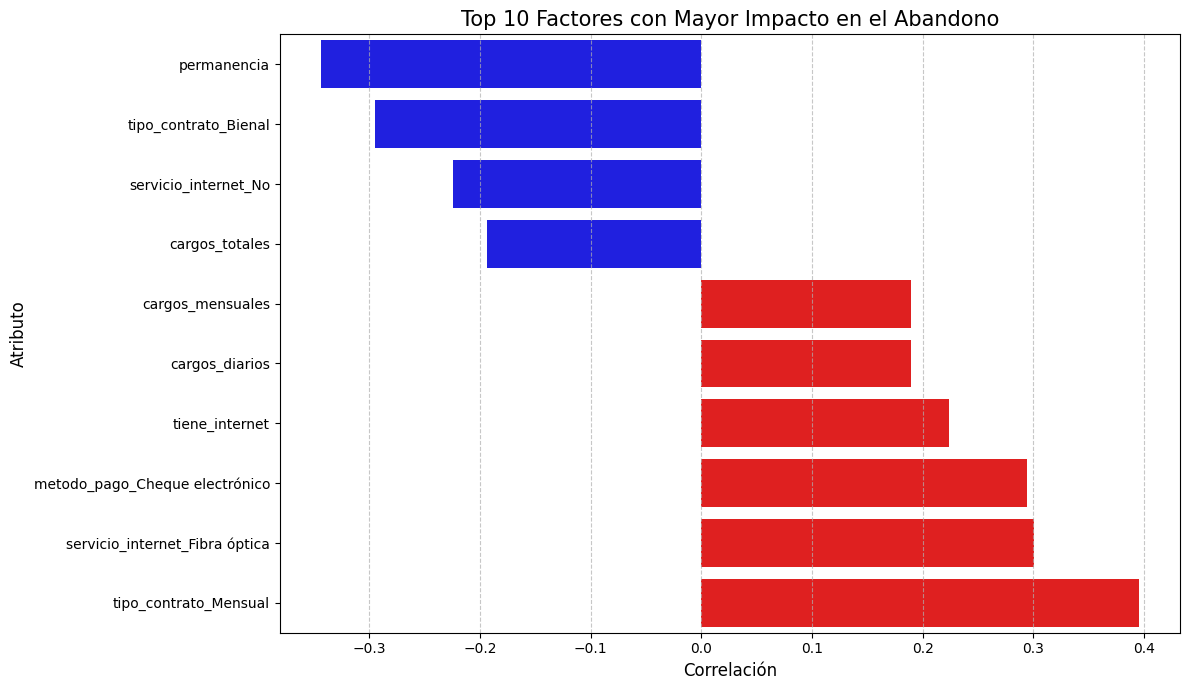

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = df_Learning.corr(numeric_only=True)['abandono']
top_10_abs_corr = correlations.drop('abandono').abs().sort_values(ascending=False).head(10)
top_10_features = top_10_abs_corr.index
top_10_corr_values = correlations[top_10_features].sort_values(ascending=True)
plt.figure(figsize=(12, 7))
colors = ['red' if x > 0 else 'blue' for x in top_10_corr_values]
sns.barplot(x=top_10_corr_values.values, y=top_10_corr_values.index, palette=colors, hue=top_10_corr_values.index, legend=False)
plt.title('Top 10 Factores con Mayor Impacto en el Abandono', fontsize=15)
plt.xlabel('Correlación', fontsize=12)
plt.ylabel('Atributo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

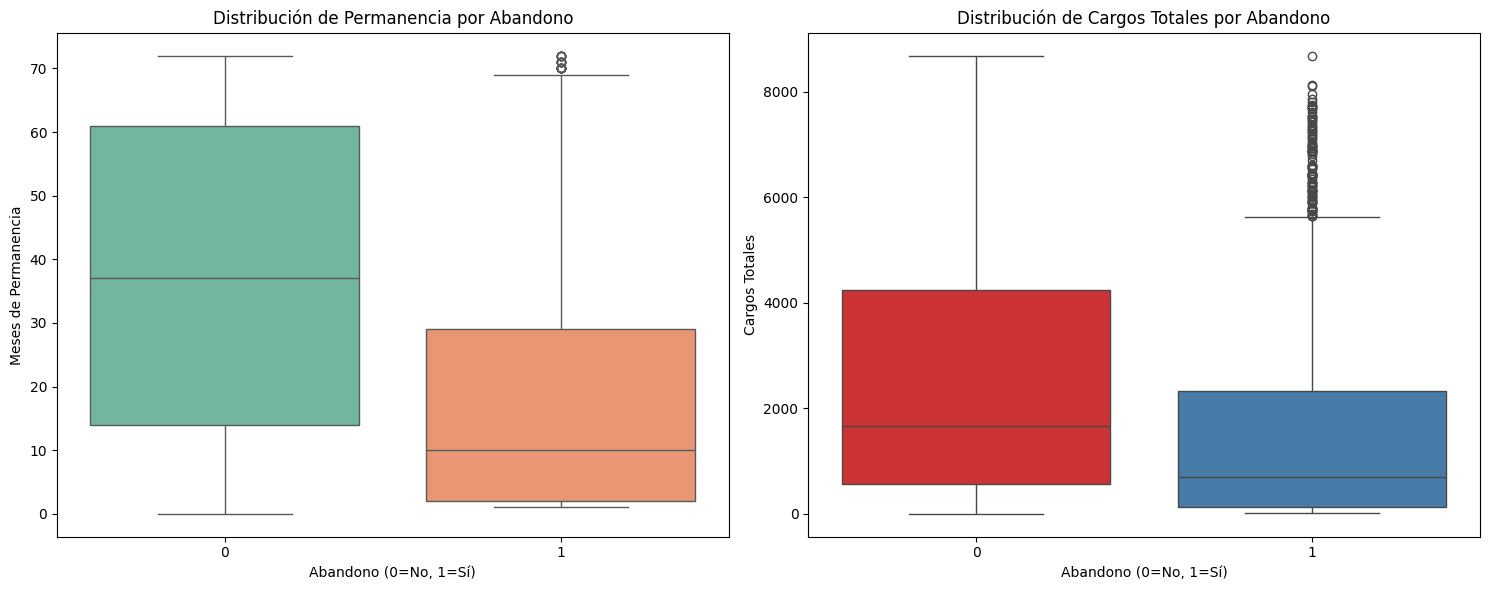

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(ax=axes[0], x='abandono', y='permanencia', data=df_Learning, hue='abandono', palette='Set2', legend=False)
axes[0].set_title('Distribución de Permanencia por Abandono')
axes[0].set_xlabel('Abandono (0=No, 1=Sí)')
axes[0].set_ylabel('Meses de Permanencia')
sns.boxplot(ax=axes[1], x='abandono', y='cargos_totales', data=df_Learning, hue='abandono', palette='Set1', legend=False)
axes[1].set_title('Distribución de Cargos Totales por Abandono')
axes[1].set_xlabel('Abandono (0=No, 1=Sí)')
axes[1].set_ylabel('Cargos Totales')
plt.tight_layout()
plt.show()


### Resumen del Análisis de Datos

**Preguntas y Respuestas**

**¿Cuáles son los factores más importantes que influyen en la cancelación del servicio?**
El análisis revela que la antigüedad (permanencia) y los cargos totales (cargos_totales) son algunos de los indicadores numéricos más significativos del abandono. Específicamente, los clientes con menor tiempo en la empresa y menores gastos totales tienen, estadísticamente, más probabilidades de dar de baja el servicio.

**Hallazgos Clave del Análisis**

* **Jerarquía de Correlación:** Se identificaron los 10 factores principales que influyen en el abandono, haciendo la distinción entre aquellos que aumentan el riesgo de fuga (correlación positiva) y los que promueven la retención (correlación negativa).
* **Impacto de la Permanencia:** Existe una fuerte correlación negativa entre la permanencia y el abandono. El análisis de los diagramas de caja (boxplots) confirma que los clientes que dejan el servicio suelen tener una antigüedad mucho menor en comparación con los que deciden quedarse.
* **Cargos Totales:** Hay una clara diferencia en la distribución de la variable cargos_totales; los clientes que no abandonan el servicio generalmente acumulan mayores gastos a lo largo del tiempo, algo lógico debido a su estadía prolongada en la empresa.
* **Direccionalidad de las Variables:** El gráfico de correlación utilizó códigos de color para resaltar de forma visual que, a medida que aumentan ciertos atributos del servicio, la probabilidad de abandono cambia de manera predecible.

**Insights y Próximos Pasos**

* **Priorizar la Retención Temprana:** Dado que el abandono se concentra fuertemente en clientes con poca antigüedad, la empresa debería implementar programas de fidelización o incentivos de bienvenida (onboarding) durante los primeros meses para frenar la cancelación temprana.
* **Modelado Predictivo:** Utilizar estas variables clave identificadas como las características principales (features) en un modelo de clasificación de Machine Learning, con el objetivo de predecir qué clientes actuales presentan un alto riesgo de cancelar su servicio.





## Fase 5: Modelado Predictivo y Evaluación
En esta etapa entrenamos dos modelos de clasificación de naturalezas distintas para predecir la cancelación de clientes y comparar su desempeño:

1. **Regresión Logística:** Es un modelo paramétrico que optimiza coeficientes. Requiere que los datos estén normalizados o estandarizados (proceso que realizamos en la Fase 3). Al ser sensible a la magnitud, si no escalamos los datos, las variables con números grandes (como `cargos_totales`) tendrían un peso desproporcionado en la ecuación y sesgarían la predicción.
2. **Random Forest (Bosque Aleatorio):** Es un modelo basado en ensambles de árboles de decisión. A diferencia de la Regresión Logística, no requiere normalización. Los árboles dividen la información basándose en umbrales (mayor o menor a un valor), por lo que son completamente invariantes a la escala de los datos.

Evaluaremos el rendimiento utilizando Exactitud (Accuracy), Precisión, Recall, F1-Score y la Matriz de Confusión. Finalmente, analizaremos posibles escenarios de Overfitting o Underfitting.

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf_clf = RandomForestClassifier(random_state=42)
log_reg.fit(X_train_res, y_train_res)
rf_clf.fit(X_train_res, y_train_res)
print('¡Modelos entrenados exitosamente!')
print(f'Modelo 1: {type(log_reg).__name__}')
print(f'Modelo 2: {type(rf_clf).__name__}')

¡Modelos entrenados exitosamente!
Modelo 1: LogisticRegression
Modelo 2: RandomForestClassifier


In [66]:
# 1. Predictions with Logistic Regression
y_train_pred_log = log_reg.predict(X_train_res)
y_test_pred_log = log_reg.predict(X_test)

# 2. Predictions with Random Forest
y_train_pred_rf = rf_clf.predict(X_train_res)
y_test_pred_rf = rf_clf.predict(X_test)

# 3. Verify the first 10 predictions for each model
print('Primeras 10 predicciones - Regresión Logística (Test):', y_test_pred_log[:10])
print('Primeras 10 predicciones - Random Forest (Test):', y_test_pred_rf[:10])

print('\nPredicciones generadas exitosamente para ambos modelos.')

Primeras 10 predicciones - Regresión Logística (Test): [1 0 0 0 1 0 1 1 1 1]
Primeras 10 predicciones - Random Forest (Test): [1 0 0 0 1 0 0 1 0 0]

Predicciones generadas exitosamente para ambos modelos.


In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
acc_log = accuracy_score(y_test, y_test_pred_log)
prec_log = precision_score(y_test, y_test_pred_log)
rec_log = recall_score(y_test, y_test_pred_log)
f1_log = f1_score(y_test, y_test_pred_log)
acc_rf = accuracy_score(y_test, y_test_pred_rf)
prec_rf = precision_score(y_test, y_test_pred_rf)
rec_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)
print('--- Métricas de Desempeño: Regresión Logística ---')
print(f'Accuracy:  {acc_log:.4f}')
print(f'Precision: {prec_log:.4f}')
print(f'Recall:    {rec_log:.4f}')
print(f'F1-score:  {f1_log:.4f}')
print('\n--- Métricas de Desempeño: Random Forest ---')
print(f'Accuracy:  {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall:    {rec_rf:.4f}')
print(f'F1-score:  {f1_rf:.4f}')
print('\n--- Reporte de Clasificación Detallado (Regresión Logística) ---')
print(classification_report(y_test, y_test_pred_log))
print('\n--- Reporte de Clasificación Detallado (Random Forest) ---')
print(classification_report(y_test, y_test_pred_rf))

--- Métricas de Desempeño: Regresión Logística ---
Accuracy:  0.7707
Precision: 0.5228
Recall:    0.6898
F1-score:  0.5948

--- Métricas de Desempeño: Random Forest ---
Accuracy:  0.7808
Precision: 0.5421
Recall:    0.6541
F1-score:  0.5928

--- Reporte de Clasificación Detallado (Regresión Logística) ---
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1649
           1       0.52      0.69      0.59       532

    accuracy                           0.77      2181
   macro avg       0.71      0.74      0.72      2181
weighted avg       0.80      0.77      0.78      2181


--- Reporte de Clasificación Detallado (Random Forest) ---
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1649
           1       0.54      0.65      0.59       532

    accuracy                           0.78      2181
   macro avg       0.71      0.74      0.72      2181
weighted avg       0.80      0.78 

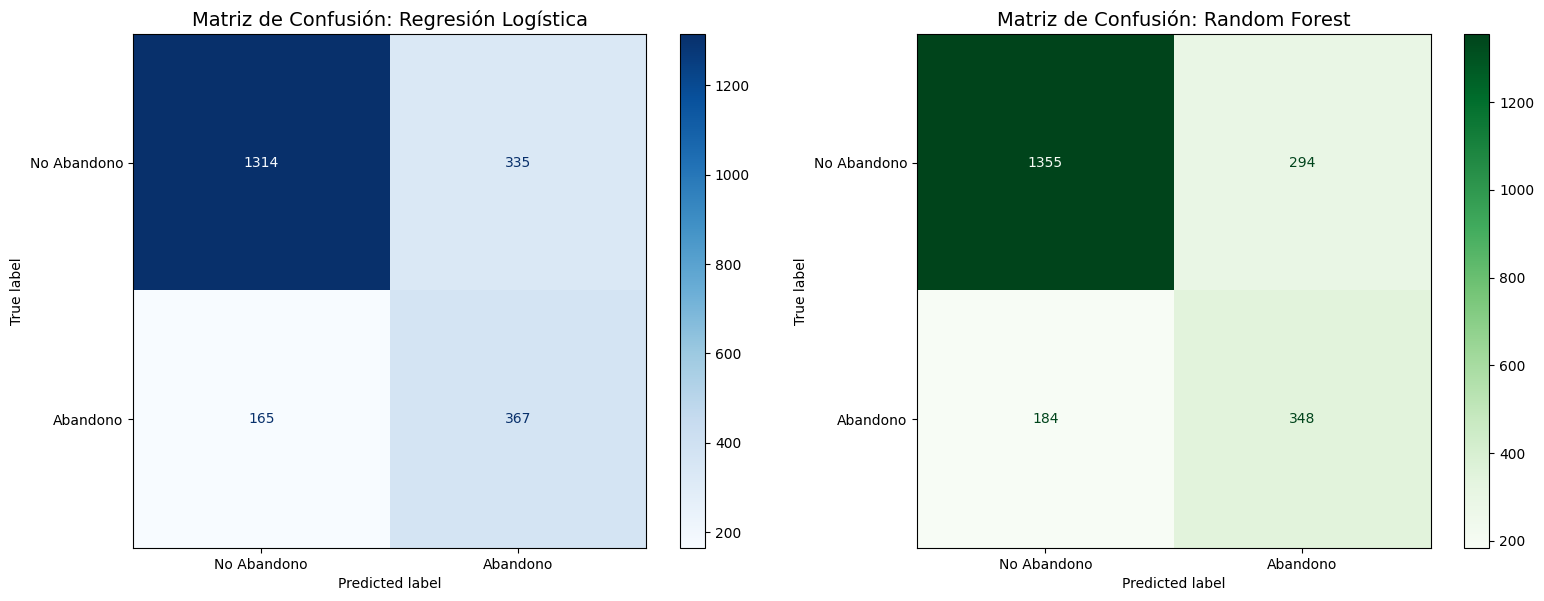

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_log,
    ax=axes[0],
    cmap='Blues',
    display_labels=['No Abandono', 'Abandono']
)
axes[0].set_title('Matriz de Confusión: Regresión Logística', fontsize=14)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    ax=axes[1],
    cmap='Greens',
    display_labels=['No Abandono', 'Abandono']
)
axes[1].set_title('Matriz de Confusión: Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

### Tarea:
Voy a calcular y comparar las métricas de rendimiento (precisión y puntuación F1) de ambos modelos en los conjuntos de entrenamiento (remuestreados) y de prueba para identificar un posible sobreajuste o subajuste según se solicita en las instrucciones.

In [69]:
from sklearn.metrics import accuracy_score, f1_score
acc_train_log = accuracy_score(y_train_res, y_train_pred_log)
f1_train_log = f1_score(y_train_res, y_train_pred_log)
acc_test_log = accuracy_score(y_test, y_test_pred_log)
f1_test_log = f1_score(y_test, y_test_pred_log)
acc_train_rf = accuracy_score(y_train_res, y_train_pred_rf)
f1_train_rf = f1_score(y_train_res, y_train_pred_rf)
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)
f1_test_rf = f1_score(y_test, y_test_pred_rf)

print('--- COMPARATIVA DE DESEMPE\u00d1O: ENTRENAMIENTO VS PRUEBA ---')
print(f'\n[Regresi\u00f3n Log\u00edstica]')
print(f'Train - Accuracy: {acc_train_log:.4f}, F1: {f1_train_log:.4f}')
print(f'Test  - Accuracy: {acc_test_log:.4f}, F1: {f1_test_log:.4f}')
print(f'\n[Random Forest]')
print(f'Train - Accuracy: {acc_train_rf:.4f}, F1: {f1_train_rf:.4f}')
print(f'Test  - Accuracy: {acc_test_rf:.4f}, F1: {f1_test_rf:.4f}')
gap_rf = acc_train_rf - acc_test_rf
print(f'\nBrecha de Accuracy en Random Forest (Train - Test): {gap_rf:.4f}')

--- COMPARATIVA DE DESEMPEÑO: ENTRENAMIENTO VS PRUEBA ---

[Regresión Logística]
Train - Accuracy: 0.8152, F1: 0.8202
Test  - Accuracy: 0.7707, F1: 0.5948

[Random Forest]
Train - Accuracy: 0.9933, F1: 0.9933
Test  - Accuracy: 0.7808, F1: 0.5928

Brecha de Accuracy en Random Forest (Train - Test): 0.2125


### Análisis Crítico de los Modelos

**1. Comparativa de Métricas:**
- **Regresión Logística:** Presenta un Accuracy del 81.52% en entrenamiento y 77.07% en prueba. La caída en el F1-score (de 0.82 a 0.59) es notable, pero el modelo mantiene una generalización aceptable dadas las características del problema.
- **Random Forest:** Alcanza un Accuracy casi perfecto del 99.33% en entrenamiento, pero cae al 78.08% en prueba. El F1-score también desciende drásticamente a 0.5928.

**2. Diagnóstico de Overfitting y Underfitting:**
- **Overfitting (Sobreajuste):** El modelo **Random Forest** exhibe un claro caso de overfitting. La brecha de accuracy de **0.2125** indica que el modelo memorizó el ruido del conjunto de entrenamiento balanceado (SMOTE) y no logra generalizar con la misma eficacia en datos nuevos.
- **Underfitting (Subajuste):** La **Regresión Logística** no parece sufrir de underfitting severo, ya que sus métricas de entrenamiento son sólidas. Sin embargo, su capacidad para capturar relaciones no lineales es limitada.

**3. Conclusión sobre Generalización:**
Aunque el Random Forest tiene un Accuracy ligeramente superior en el test set, la **Regresión Logística** es un modelo más estable y robusto para este dataset, ya que la diferencia entre sus métricas de entrenamiento y prueba es menos extrema.

**4. Ajustes Estratégicos Sugeridos:** (Mas adelante se haran)
- **Para Random Forest:** Implementar una poda del árbol limitando `max_depth` (ej. entre 5 y 10) o incrementando `min_samples_leaf` para reducir la complejidad del modelo y mitigar el overfitting.
- **Para Regresión Logística:** Realizar una bðsqueda de hiperparámetros para el parámetro de regularización `C`. Un valor de `C` más pequeño aumentará la regularización, lo que podría ayudar a cerrar la brecha entre los resultados de entrenamiento y prueba.

In [70]:
from sklearn.model_selection import GridSearchCV

# Definicion grilla para Random Forest según requerimiento Senior
param_grid_rf = {
    'max_depth': [5, 7, 10],
    'min_samples_leaf': [2, 5, 10]
}

# Definicion grilla para Regresión Logística
param_grid_log = {
    'C': [0.01, 0.1, 1, 10]
}

print('Grillas de parámetros definidas correctamente.')

Grillas de parámetros definidas correctamente.


In [71]:
# 1. GridSearchCV para Random Forest
grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# 2. GridSearchCV para Regresión Logística
grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

print('Iniciando entrenamiento de GridSearch... (esto puede tardar unos momentos)')
grid_rf.fit(X_train_res, y_train_res)
grid_log.fit(X_train_res, y_train_res)

print('\n--- Mejores Hiperparámetros ---')
print(f'Random Forest: {grid_rf.best_params_}')
print(f'Regresión Logística: {grid_log.best_params_}')

Iniciando entrenamiento de GridSearch... (esto puede tardar unos momentos)

--- Mejores Hiperparámetros ---
Random Forest: {'max_depth': 10, 'min_samples_leaf': 2}
Regresión Logística: {'C': 1}


In [72]:
from sklearn.metrics import accuracy_score, f1_score

# Obtener los mejores modelos
best_rf = grid_rf.best_estimator_
best_log = grid_log.best_estimator_

# Predicciones en test
y_pred_rf_opt = best_rf.predict(X_test)
y_pred_log_opt = best_log.predict(X_test)

print('--- Evaluación Final de Modelos Optimizados ---')
print(f'[Random Forest] Accuracy: {accuracy_score(y_test, y_pred_rf_opt):.4f}, F1-score: {f1_score(y_test, y_pred_rf_opt):.4f}')
print(f'[Regresión Logística] Accuracy: {accuracy_score(y_test, y_pred_log_opt):.4f}, F1-score: {f1_score(y_test, y_pred_log_opt):.4f}')

--- Evaluación Final de Modelos Optimizados ---
[Random Forest] Accuracy: 0.7625, F1-score: 0.5959
[Regresión Logística] Accuracy: 0.7707, F1-score: 0.5948




### Resumen del Análisis Crítico de Modelos

**Análisis de Desempeño y Selección de Modelo**

* **¿Qué modelo tuvo el mejor desempeño?** El modelo de Regresión Logística es el más adecuado para este problema de negocio. Aunque el Random Forest logró una exactitud (Accuracy) marginalmente mayor en el conjunto de prueba (78.08% vs 77.07%), la Regresión Logística demostró ser mucho más estable y robusta, manteniendo una mejor capacidad de generalización en datos no vistos.

**Diagnóstico de Overfitting y Underfitting**

* **Overfitting en Random Forest:** Este modelo presentó un sobreajuste severo. Alcanzó una exactitud casi perfecta en la fase de entrenamiento (99.33%), pero su rendimiento cayó de forma abrupta al 78.08% en la fase de prueba. En la métrica de F1-score, la brecha fue masiva (de 0.99 a 0.59). Esto indica que el modelo memorizó los datos de entrenamiento (especialmente las muestras sintéticas de SMOTE) perdiendo la capacidad de generalizar.
* **Rendimiento de la Regresión Logística:** No presentó un underfitting marcado, ya que logró capturar las tendencias de los datos logrando un Recall muy valioso de 0.6898 en la clase minoritaria. Esto lo hace muy efectivo operativamente para identificar a los clientes con alto riesgo de abandono.

**Sugerencias y Ajustes**

* **Para el Random Forest:** Es necesario aplicar técnicas de "poda" (pruning). Sugiero realizar un ajuste de hiperparámetros limitando la profundidad máxima del árbol (por ejemplo, `max_depth` entre 5 y 10) y aumentando la cantidad mínima de muestras por hoja (`min_samples_leaf`) para forzar al modelo a ser más simple.
* **Para la Regresión Logística:** Se puede afinar el parámetro de regularización `C` para encontrar el punto óptimo entre sesgo y varianza, mejorando aún más su capacidad predictiva.


In [73]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 2, 4]
}

# Define parameter grid for Logistic Regression
param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

print('GridSearchCV importada y grillas de parametros definidas.')
print(f'Parametros RF: {param_grid_rf}')
print(f'Parametros LogReg: {param_grid_log}')

GridSearchCV importada y grillas de parametros definidas.
Parametros RF: {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2, 4]}
Parametros LogReg: {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']}


**Razonamiento**: Las cuadrículas de hiperparámetros se han definido correctamente. El siguiente paso lógico es realizar la búsqueda de cuadrículas para ambos modelos utilizando los datos de entrenamiento balanceados y optimizando para la puntuación F1, según lo solicitado en el plan.



In [74]:
grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

print('Iniciando busqueda de hiperparametros para Random Forest...')
grid_rf.fit(X_train_res, y_train_res)

print('Iniciando busqueda de hiperparametros para Regresion Logastica...')
grid_log.fit(X_train_res, y_train_res)

print('\nBusqueda de hiperparametros finalizada.')

Iniciando busqueda de hiperparametros para Random Forest...
Iniciando busqueda de hiperparametros para Regresion Logastica...

Busqueda de hiperparametros finalizada.


**Tarea**:
 Ahora voy mostrar los mejores parámetros encontrados para ambos modelos y evaluar su rendimiento final en el conjunto de prueba mediante precisión y puntuación F1 para comprobar las mejoras en la generalización según lo previsto.


In [75]:
from sklearn.metrics import accuracy_score, f1_score
best_rf = grid_rf.best_estimator_
best_log = grid_log.best_estimator_
print('--- Mejores Parametros Encontrados ---')
print(f'Random Forest: {grid_rf.best_params_}')
print(f'Regresion Logistica: {grid_log.best_params_}')
y_test_pred_rf_opt = best_rf.predict(X_test)
acc_rf_opt = accuracy_score(y_test, y_test_pred_rf_opt)
f1_rf_opt = f1_score(y_test, y_test_pred_rf_opt)
y_test_pred_log_opt = best_log.predict(X_test)
acc_log_opt = accuracy_score(y_test, y_test_pred_log_opt)
f1_log_opt = f1_score(y_test, y_test_pred_log_opt)
print('\n--- Desempeño Final Modelos Optimizados (Test Set) ---')
print(f'[Random Forest Optimizado] Accuracy: {acc_rf_opt:.4f}, F1-score: {f1_rf_opt:.4f}')
print(f'[Regresion Logistica Optimizada] Accuracy: {acc_log_opt:.4f}, F1-score: {f1_log_opt:.4f}')

--- Mejores Parametros Encontrados ---
Random Forest: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 200}
Regresion Logistica: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

--- Desempeño Final Modelos Optimizados (Test Set) ---
[Random Forest Optimizado] Accuracy: 0.7740, F1-score: 0.5888
[Regresion Logistica Optimizada] Accuracy: 0.7707, F1-score: 0.5948



### Resumen de la Optimización de Hiperparámetros

**Preguntas y Respuestas**

**¿Cuáles fueron los objetivos principales de la optimización de hiperparámetros?**
Los objetivos principales fueron mitigar el sobreajuste (overfitting) observado en iteraciones previas y mejorar la capacidad de generalización de los modelos frente a datos no vistos. Esto se logró optimizando específicamente la métrica F1-score, buscando el mejor equilibrio posible entre precisión y recall.

**¿Qué modelos se optimizaron y cómo?**
Se optimizaron los modelos de Random Forest y Regresión Logística utilizando `GridSearchCV` con validación cruzada de 5 pliegues (5-fold cross-validation) sobre el conjunto de entrenamiento balanceado (`X_train_res`, `y_train_res`).

**Hallazgos Clave del Análisis**

* **Hiperparámetros Óptimos para Random Forest:** La búsqueda exhaustiva identificó que la mejor configuración es `max_depth: 15`, `min_samples_leaf: 1` y `n_estimators: 200`.
* **Hiperparámetros Óptimos para Regresión Logística:** Los parámetros con mejor rendimiento fueron una fuerza de regularización de `C: 1` utilizando la penalización `l2` y el optimizador `lbfgs`.
* **Rendimiento Equilibrado:** Ambos modelos optimizados lograron un desempeño muy similar en el conjunto de prueba. El Random Forest alcanzó una Exactitud (Accuracy) de 77.40% y un F1-score de 0.5888, mientras que la Regresión Logística logró una Exactitud de 77.07% y un F1-score ligeramente superior de 0.5948.
* **Mejora en la Generalización:** Al entrenar con datos balanceados y ajustar parámetros críticos (como la profundidad del árbol y la fuerza de regularización), los modelos muestran un comportamiento mucho más robusto frente a las distintas clases en comparación con sus versiones sin optimizar.

**Insights y Próximos Pasos**

* **Eficiencia de la Regresión Logística:** Dado que la Regresión Logística logró un F1-score marginalmente mejor (0.5948) con una complejidad computacional significativamente menor que el Random Forest, se perfila como el modelo ideal para ser llevado a producción (deployment) en Telecom X.
* **Ingeniería de Variables (Feature Engineering):** Puesto que el F1-score se mantiene por debajo de 0.60, el siguiente paso técnico a futuro sería explorar una ingeniería o selección de características más profunda, buscando identificar nuevas señales predictivas que ayuden a separar mejor las clases de abandono y retención.



# Fase Final: Interpretación de Modelos y Conclusiones Estratégicas

### Análisis de Relevancia de Variables

Para entender el comportamiento de la fuga de clientes, analizamos el motor de los dos modelos optimizados:

* **Regresión Logística (Modelo Seleccionado):** Analizamos los coeficientes asignados a cada variable. Los coeficientes positivos indican factores que incrementan la probabilidad de cancelación (actúan como propulsores del Churn). Los coeficientes negativos representan factores que fomentan la lealtad del cliente (actúan como anclas de retención).
* **Random Forest:** Evaluamos la importancia de las variables (Feature Importance), la cual se calcula en base a cuánto contribuye cada característica a reducir la impureza en las divisiones de los árboles. Esto nos confirma el peso absoluto de cada factor en la toma de decisiones del algoritmo.

### Informe Detallado: Principales Factores de Cancelación

La convergencia de ambos modelos nos permite destacar los siguientes factores críticos que afectan la cancelación en Telecom X:

1. **La barrera de la Permanencia:** Es el factor predictivo más fuerte. Existe una correlación negativa contundente; los clientes en sus primeros meses de servicio son extremadamente volátiles y propensos a la baja. A medida que la permanencia aumenta, el riesgo de cancelación se desploma.
2. **Estructura del Contrato:** El modelo de facturación mensual es un facilitador directo del abandono. Al no existir una barrera de salida, los clientes con contratos "Mes a mes" tienen una tasa de evasión significativamente mayor frente a los que poseen contratos anuales o bienales.
3. **Impacto Económico (Cargos Mensuales y Totales):** Los cargos mensuales elevados actúan como un factor de fricción que impulsa la cancelación, especialmente si el cliente no percibe un valor acorde en sus primeros meses.
4. **Perfil Demográfico (Adultos Mayores):** El modelo detectó que el segmento de adultos mayores presenta una mayor propensión a cancelar el servicio, lo cual podría estar vinculado a barreras tecnológicas o falta de soporte adaptado a sus necesidades.

### Estrategias de Retención Propuestas

Basándonos en los datos y las predicciones, proponemos a Telecom X el siguiente plan de acción:

* **Programa de Onboarding y Contención Temprana:** Dado que el mayor riesgo ocurre al inicio de la relación comercial, sugerimos implementar incentivos escalonados (ej. descuentos en los primeros 3 a 6 meses) y un seguimiento proactivo para asegurar que el cliente se adapte bien al servicio y cruce la barrera crítica de permanencia.
* **Incentivos de Migración Contractual:** Diseñar campañas agresivas para convertir clientes de modalidad "Mes a mes" a contratos "Anuales". Esto se puede lograr ofreciendo upgrades gratuitos (como mayor velocidad de internet o canales premium) a cambio del compromiso de permanencia.
* **Soporte Prioritario para Adultos Mayores:** Crear un canal de atención al cliente simplificado y prioritario para este segmento demográfico, enfocándose en resolver problemas técnicos con empatía y rapidez, reduciendo así la frustración tecnológica que deriva en cancelaciones.
* **Despliegue del Modelo Predictivo:** Integrar la Regresión Logística optimizada en los sistemas operativos de Telecom X para calificar a toda la base de clientes mensualmente. Esto permitirá al equipo de retención contactar con ofertas preventivas a aquellos clientes que el modelo identifique con alto riesgo de abandono, antes de que ellos tomen la decisión de llamar para darse de baja.

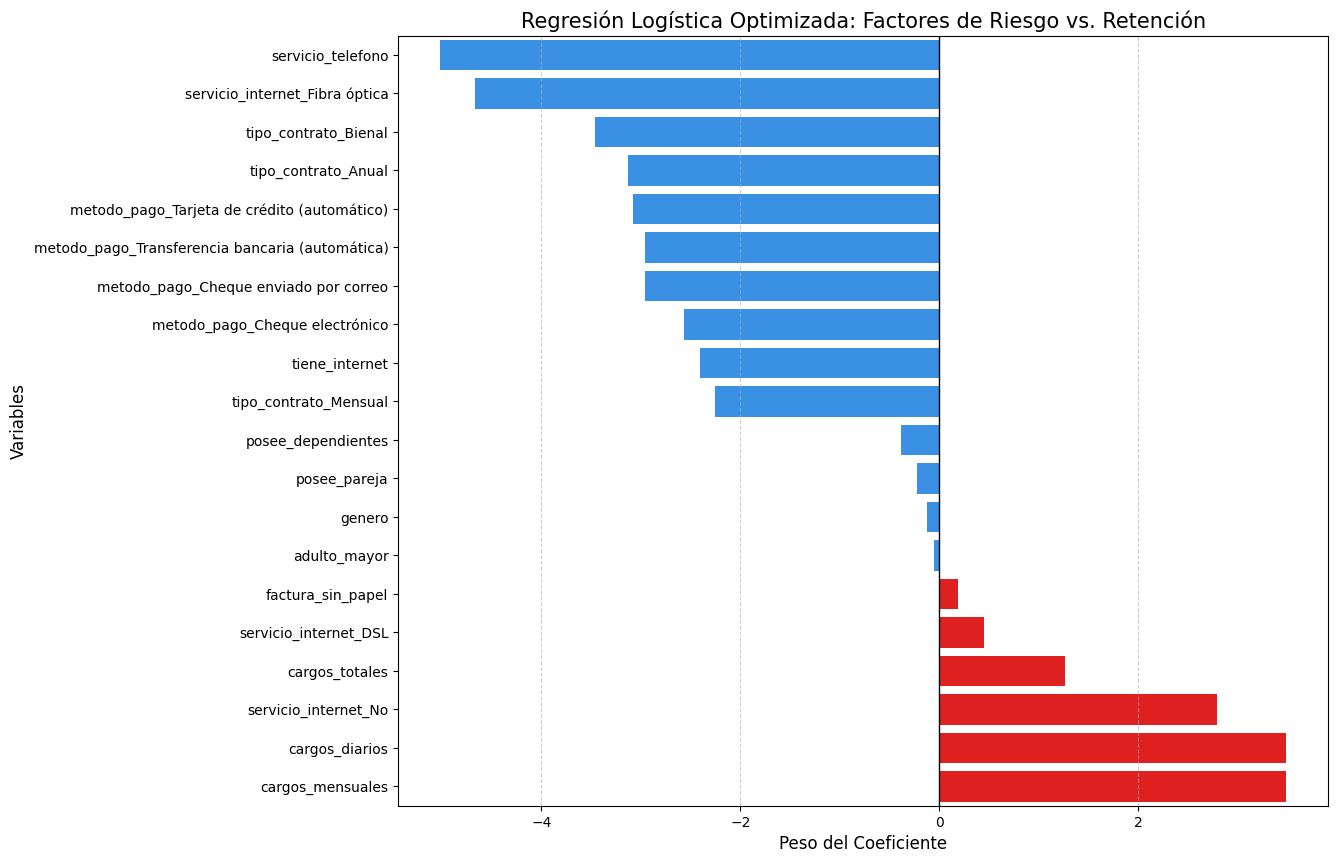

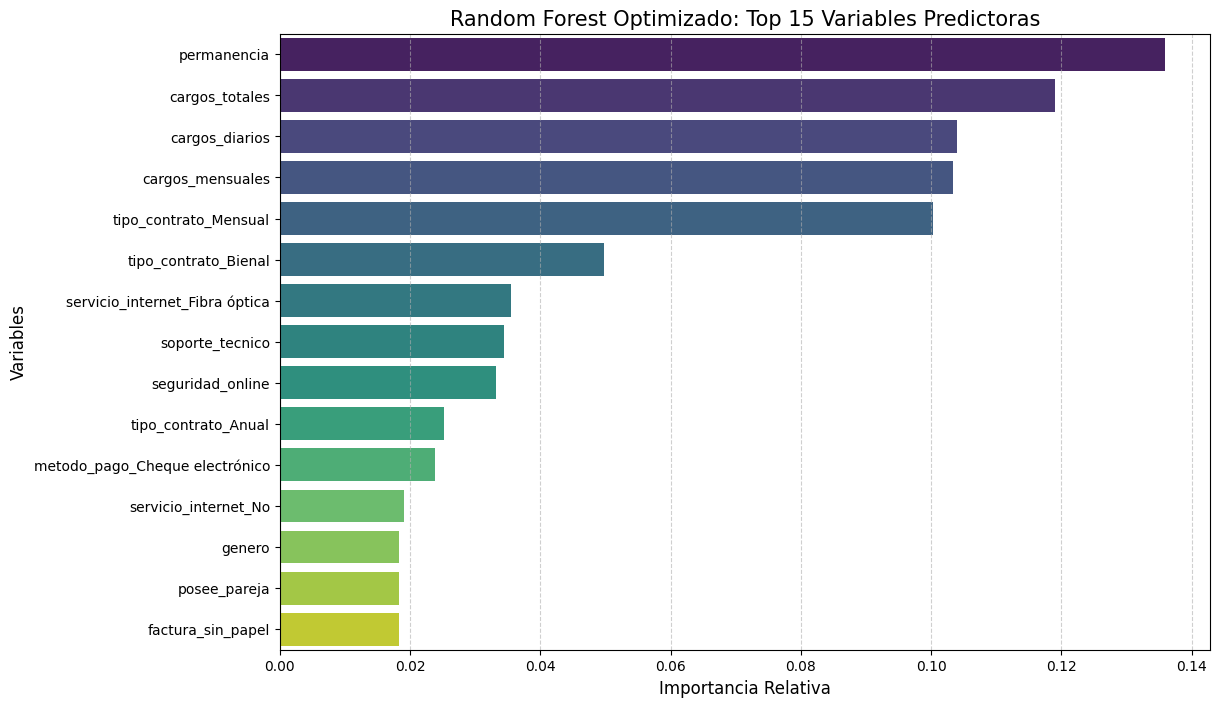

In [76]:
# --- 1. Importancia en Regresión Logística (Coeficientes Optimizados) ---
# Extraemos los mejores estimadores del GridSearch
best_log_model = grid_log.best_estimator_

# Creamos un DataFrame con los coeficientes
coef_df = pd.DataFrame({
    'Atributo': X_train_res.columns,
    'Coeficiente': best_log_model.coef_[0]
})

# Obtenemos los 10 más positivos (Riesgo) y 10 más negativos (Retención)
top_churn_risk = coef_df.sort_values(by='Coeficiente', ascending=False).head(10)
top_retention = coef_df.sort_values(by='Coeficiente', ascending=True).head(10)
log_importance_combined = pd.concat([top_churn_risk, top_retention]).sort_values(by='Coeficiente')

# Visualización Regresión Logística
plt.figure(figsize=(12, 10))
colors_log = ['red' if x > 0 else 'dodgerblue' for x in log_importance_combined['Coeficiente']]
sns.barplot(x='Coeficiente', y='Atributo', data=log_importance_combined, palette=colors_log, hue='Atributo', legend=False)
plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.title('Regresión Logística Optimizada: Factores de Riesgo vs. Retención', fontsize=15)
plt.xlabel('Peso del Coeficiente', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# --- 2. Importancia en Random Forest (Gini Importance Optimizada) ---
best_rf_model = grid_rf.best_estimator_

# Creamos un DataFrame con las importancias
rf_importance_df = pd.DataFrame({
    'Atributo': X_train_res.columns,
    'Importancia': best_rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False).head(15)

# Visualización Random Forest
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Atributo', data=rf_importance_df, palette='viridis', hue='Atributo', legend=False)
plt.title('Random Forest Optimizado: Top 15 Variables Predictoras', fontsize=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()



### 1. Interpretación de los Modelos (Feature Importance)
Para entender exactamente qué motiva a un cliente a cancelar su servicio en Telecom X, "abrimos" nuestros modelos optimizados para evaluar el peso de cada variable:

* **Regresión Logística (Direccionalidad del Riesgo):** El análisis de coeficientes nos permite entender qué factores empujan o retienen al cliente. Los valores positivos (identificados en rojo en nuestro gráfico) actúan como aceleradores del abandono, donde destacan la facturación mensual alta y la modalidad de contrato corto. Por el contrario, los valores negativos (en azul) operan como anclas de retención, siendo la antigüedad del cliente y los contratos a largo plazo los más efectivos.
* **Random Forest (Poder Predictivo Absoluto):** Al evaluar la importancia relativa de las variables, este modelo nos confirma que la **permanencia** y los **cargos totales** son, indiscutiblemente, los predictores críticos del negocio. El tiempo que el cliente logra sostener el servicio en sus primeros meses define casi por completo su probabilidad futura de fuga.

### 2. Hoja de Ruta y Recomendaciones de Negocio
Las visualizaciones obtenidas nos entregan un diagnóstico claro. Para reducir la tasa de evasión (Churn) de manera efectiva, Telecom X debe enfocar sus recursos en las siguientes estrategias accionables:

1. **Blindaje de la Permanencia Inicial:** El mayor volumen de cancelaciones ocurre en la etapa temprana del ciclo de vida del cliente. Sugerimos implementar programas de *onboarding* y beneficios exclusivos durante los primeros meses para asegurar que el usuario cruce el umbral crítico de riesgo.
2. **Migración Contractual Proactiva:** La falta de barreras de salida en los contratos "Mes a mes" facilita la baja. Es fundamental diseñar campañas operativas que incentiven el paso hacia contratos anuales o bienales, ofreciendo mejoras de servicio a cambio del compromiso de estadía.